In [1]:
import tensorflow as tf
from src.dataset import build_yolo_dataset
import numpy as np
from src.constants import ANCHORS, GRID_SIZE, IMAGE_SIZE, NUM_CLASSES
from src.model import build_model

#### Loading the trained model to calculate predictions

In [2]:
model = build_model()
checkpoint = tf.train.Checkpoint(model=model)
checkpoint.restore(
    "checkpoints/norm_loss_model/ckpt-44"
).expect_partial()

#### Compute predctions

In [18]:
def compute_preds(dataset):
    if dataset == "train":
        dataset = build_yolo_dataset(batch_size= 16, split= "train", shuffle= False)
        for batch in dataset.take(1):
            images = batch["image"]
            true_boxes = batch["boxes"]
            true_labels = batch["labels"]
            targets = batch["targets"]
        print("Images shape:", images.shape)
        print("Targets shape:", targets.shape)
        preds = model(images, training=False)
        print("Predictions shape:", preds.shape)
    elif dataset== "val":
        dataset = build_yolo_dataset(batch_size= 16, split= "val", shuffle = False)
        for batch in dataset.take(1):
            images = batch["image"]
            true_boxes = batch["boxes"]
            true_labels = batch["labels"]
            targets = batch["targets"]
        preds = model(images, training=False)
    else: 
        raise ValueError("Use train or val strings as arg")
    return images, true_boxes, true_labels, targets, preds, dataset


In [19]:
images, true_boxes, true_labels, targets, preds, dataset = compute_preds("val")

In [21]:
target = train_targets[0]
pred = train_preds[0]

positive_indices = tf.where(target[..., 0] == 1)

for cell_y, cell_x, anchor_idx in positive_indices.numpy():

    target_values = target[cell_y, cell_x, anchor_idx]
    pred_values = pred[cell_y, cell_x, anchor_idx]

    objectness = float(tf.sigmoid(pred_values[0]))

    class_probs = tf.nn.softmax(pred_values[5:])
    pred_class = int(tf.argmax(class_probs))
    pred_class_prob = float(class_probs[pred_class])

    true_class = int(tf.argmax(target_values[5:]))

    print(f"\nCell=(x={cell_x}, y={cell_y}), Anchor={anchor_idx}")
    print(f"True class: {true_class}")
    print(
        f"Pred class: {pred_class}, "
        f"probability: {pred_class_prob:.3f}"
    )
    print(
        f"Objectness: target={float(target_values[0]):.3f}, "
        f"prediction={objectness:.3f}"
    )

    print(
        f"tx: target={float(target_values[1]):.3f}, "
        f"pred={float(pred_values[1]):.3f}"
    )
    print(
        f"ty: target={float(target_values[2]):.3f}, "
        f"pred={float(pred_values[2]):.3f}"
    )
    print(
        f"tw: target={float(target_values[3]):.3f}, "
        f"pred={float(pred_values[3]):.3f}"
    )
    print(
        f"th: target={float(target_values[4]):.3f}, "
        f"pred={float(pred_values[4]):.3f}"
    )


Cell=(x=6, y=3), Anchor=1
True class: 14
Pred class: 14, probability: 0.987
Objectness: target=1.000, prediction=0.380
tx: target=0.258, pred=0.473
ty: target=0.342, pred=0.769
tw: target=-0.492, pred=-0.374
th: target=-0.671, pred=-0.835

Cell=(x=7, y=8), Anchor=2
True class: 12
Pred class: 12, probability: 0.353
Objectness: target=1.000, prediction=0.962
tx: target=0.336, pred=0.248
ty: target=0.029, pred=0.224
tw: target=-0.444, pred=-0.519
th: target=-0.474, pred=-0.414


#### Decoding the raw predictions into "Detections"

In [27]:
def calculate_detections(pred):

    grid_h, grid_w = GRID_SIZE

    pred = tf.convert_to_tensor(pred, dtype=tf.float32)

    raw_objectness = pred[..., 0]
    tx = pred[..., 1]
    ty = pred[..., 2]
    tw = pred[..., 3]
    th = pred[..., 4]
    raw_class_logits = pred[..., 5:]

    objectness = tf.sigmoid(raw_objectness)

    class_probs = tf.nn.softmax(
        raw_class_logits,
        axis=-1
    )

    class_ids = tf.argmax(
        class_probs,
        axis=-1,
        output_type=tf.int32
    )

    class_prob = tf.reduce_max(
        class_probs,
        axis=-1
    )

    confidence = objectness * class_prob

    # Grid
    cell_y, cell_x = tf.meshgrid(
        tf.range(grid_h, dtype=tf.float32),
        tf.range(grid_w, dtype=tf.float32),
        indexing="ij"
    )

    cell_x = cell_x[..., None]
    cell_y = cell_y[..., None]

    # Decode center
    cx = (tx + cell_x) / grid_w
    cy = (ty + cell_y) / grid_h

    # Anchors
    anchors = tf.constant(
        ANCHORS,
        dtype=tf.float32
    )

    anchor_w = anchors[:, 0][None, None, :]
    anchor_h = anchors[:, 1][None, None, :]

    bw = tf.exp(tw) * anchor_w
    bh = tf.exp(th) * anchor_h

    # Convert to corners
    xmin = cx - bw / 2
    ymin = cy - bh / 2
    xmax = cx + bw / 2
    ymax = cy + bh / 2

    boxes = tf.stack(
        [xmin, ymin, xmax, ymax],
        axis=-1
    )

    # Normalize -> pixels
    boxes *= tf.constant(
        [
            IMAGE_SIZE[1],
            IMAGE_SIZE[0],
            IMAGE_SIZE[1],
            IMAGE_SIZE[0]
        ],
        dtype=tf.float32
    )

    # Flatten
    boxes = tf.reshape(boxes, (-1, 4))
    confidence = tf.reshape(confidence, (-1,))
    class_ids = tf.reshape(class_ids, (-1,))
    objectness = tf.reshape(objectness, (-1,))
    class_prob = tf.reshape(class_prob, (-1,))

    return {
        "boxes": boxes,
        "confidence": confidence,
        "class_ids": class_ids,
        "objectness": objectness,
        "class_prob": class_prob,
    }

#### Class-wise Non Max Suppression

In [11]:
def nms(detections):

    boxes = detections["boxes"]
    confidence = detections["confidence"]
    class_ids = detections["class_ids"]

    # --------------------------------------------------
    # Build [num_predictions, NUM_CLASSES] score matrix
    # --------------------------------------------------

    scores = tf.one_hot(
        class_ids,
        depth=NUM_CLASSES,
        dtype=tf.float32
    )

    scores *= confidence[:, None]

    # --------------------------------------------------
    # Add batch dimensions
    # --------------------------------------------------

    boxes = boxes[None, :, None, :]
    scores = scores[None, :, :]

    # --------------------------------------------------
    # Class-wise NMS
    # --------------------------------------------------

    nms_boxes, nms_scores, nms_classes, valid_detections = \
        tf.image.combined_non_max_suppression(
            boxes=boxes,
            scores=scores,
            max_output_size_per_class=50,
            max_total_size=50,
            iou_threshold=0.5,
            score_threshold=0.5,
            clip_boxes=False
        )

    num_valid = int(valid_detections[0])

    final_detections = []

    for i in range(num_valid):

        box = nms_boxes[0, i].numpy().tolist()

        # Clip to image boundaries
        box = [
            max(0.0, min(224.0, x))
            for x in box
        ]

        final_detections.append({
            "box": box,
            "class_id": int(nms_classes[0, i].numpy()),
            "confidence": float(nms_scores[0, i].numpy())
        })

    return final_detections

#### Simple Non Max Suppression

In [ ]:
# Simple Non Max Suppression
'''
bxs = [b["box"] for b in detections]
tensor_boxes = tf.convert_to_tensor(bxs)
conf_score = [b["confidence"] for b in detections]
tensor_score = tf.convert_to_tensor(conf_score)
nms_idx = tf.image.combined_non_max_suppression(tensor_boxes, tensor_score, 50, iou_threshold = 0.5, score_threshold= 0.5)
filtered_detections = [detections[i] for i in nms_idx.numpy()]

print("Total predictions:", len(detections))
print("After confidence filtering:", len(filtered_detections))

for d in filtered_detections:
    d["box"] = [
        max(0, min(224, x))
        for x in d["box"]
    ]'''

Total predictions: 588
After confidence filtering: 25


#### IoU function

In [6]:
def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2= box_a
    bx1, by1, bx2, by2= box_b

    inter_x1= max(ax1, bx1)
    inter_y1= max(ay1, by1)
    inter_x2= min(ax2, bx2)
    inter_y2= min(ay2, by2)

    inter_w= max(0.0, inter_x2 - inter_x1)
    inter_h= max(0.0, inter_y2 - inter_y1)
    intersection= inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - intersection

    if union <= 0:
        return 0.0

    return intersection/union

#### Match predictions to ground truth

There are two rules we need:
   1. The classes must match.
   2. IoU must be above a threshold.


In [22]:
def match_detections(
    detections,
    gt_boxes,
    gt_labels,
    iou_threshold=0.5
):
    matched_gt = set()

    true_positives = []
    false_positives = []

    # Extra information about WHY each FP happened
    wrong_class_fps = []
    localization_fps = []
    background_fps = []

    detections = sorted(
        detections,
        key=lambda d: d["confidence"],
        reverse=True
    )

    for pred in detections:

        # --------------------------------------------------
        # First: find best GT regardless of class
        # --------------------------------------------------

        best_any_iou = 0.0
        best_any_gt_idx = None

        for gt_idx, gt_box in enumerate(gt_boxes):

            iou = box_iou(
                pred["box"],
                gt_box
            )

            if iou > best_any_iou:
                best_any_iou = iou
                best_any_gt_idx = gt_idx

        # --------------------------------------------------
        # Second: find best unmatched GT of SAME class
        # --------------------------------------------------

        best_iou = 0.0
        best_gt_idx = None

        for gt_idx, (gt_box, gt_class) in enumerate(
            zip(gt_boxes, gt_labels)
        ):

            if gt_idx in matched_gt:
                continue

            if pred["class_id"] != int(gt_class):
                continue

            iou = box_iou(
                pred["box"],
                gt_box
            )

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        # --------------------------------------------------
        # True positive
        # --------------------------------------------------

        if best_iou >= iou_threshold:

            matched_gt.add(best_gt_idx)

            true_positives.append({
                "prediction": pred,
                "gt_idx": best_gt_idx,
                "iou": best_iou,
            })

        # --------------------------------------------------
        # False positive
        # --------------------------------------------------

        else:

            false_positives.append(pred)

            # ----------------------------------------------
            # Classify WHY this was an FP
            # ----------------------------------------------

            if best_any_iou >= iou_threshold:

                # Good overlap with an object, but the
                # predicted class was wrong.
                wrong_class_fps.append({
                    "prediction": pred,
                    "gt_idx": best_any_gt_idx,
                    "iou": best_any_iou,
                    "true_class": int(
                        gt_labels[best_any_gt_idx]
                    ),
                })

            elif best_any_iou > 0.0:

                # Prediction overlaps an object, but
                # localization is not good enough.
                localization_fps.append({
                    "prediction": pred,
                    "gt_idx": best_any_gt_idx,
                    "iou": best_any_iou,
                    "true_class": int(
                        gt_labels[best_any_gt_idx]
                    ),
                })

            else:

                # No meaningful overlap with any GT.
                background_fps.append({
                    "prediction": pred,
                })

    # ------------------------------------------------------
    # False negatives
    # ------------------------------------------------------

    false_negatives = [
        {
            "box": gt_boxes[i],
            "class_id": int(gt_labels[i]),
            "gt_idx": i,
        }
        for i in range(len(gt_boxes))
        if i not in matched_gt
    ]

    return (
        true_positives,
        false_positives,
        false_negatives,
        wrong_class_fps,
        localization_fps,
        background_fps,
    )

In [ ]:
dataset = build_yolo_dataset(
    batch_size=16,
    split="val",
    shuffle=False
)

all_true_positives = []
all_false_positives = []
all_false_negatives = []
all_wrong_class_fps = []
all_localization_fps = []
all_background_fps = []

total_final_detections = 0
num_images = 0

for batch_idx, batch in enumerate(dataset):

    images = batch["image"]
    true_boxes = batch["boxes"]
    true_labels = batch["labels"]

    preds = model(images, training = False)

    batch_size = images.shape[0]

    for image_idx in range(batch_size):

        pred = preds[image_idx]

        detections = calculate_detections(pred)
        final_detections = nms(detections)

        total_final_detections += len(final_detections)
        num_images += 1

        gt_boxes = []
        gt_labels = []

        for box, label in zip(
            true_boxes[image_idx].numpy(),
            true_labels[image_idx].numpy()
        ):
            # Ignore padded boxes
            if np.all(box == 0):
                continue

            gt_boxes.append(box)
            gt_labels.append(int(label))

        # --------------------------------------------------
        # Match predictions to ground truth
        # --------------------------------------------------

        (tp, fp, fn, wrong_class, localization, background) = match_detections(
              final_detections,
              gt_boxes,
              gt_labels,
              iou_threshold=0.5)

        all_true_positives.extend(tp)
        all_false_positives.extend(fp)
        all_false_negatives.extend(fn)

        all_wrong_class_fps.extend(wrong_class)
        all_localization_fps.extend(localization)
        all_background_fps.extend(background)

    print(f"Processed validation batch {batch_idx + 1}")

Processed validation batch 1
Processed validation batch 2
Processed validation batch 3
Processed validation batch 4
Processed validation batch 5
Processed validation batch 6
Processed validation batch 7
Processed validation batch 8
Processed validation batch 9
Processed validation batch 10
Processed validation batch 11
Processed validation batch 12
Processed validation batch 13
Processed validation batch 14
Processed validation batch 15
Processed validation batch 16
Processed validation batch 17
Processed validation batch 18
Processed validation batch 19
Processed validation batch 20
Processed validation batch 21
Processed validation batch 22
Processed validation batch 23
Processed validation batch 24
Processed validation batch 25
Processed validation batch 26
Processed validation batch 27
Processed validation batch 28
Processed validation batch 29
Processed validation batch 30
Processed validation batch 31
Processed validation batch 32
Processed validation batch 33
Processed validatio

In [24]:
print(
    "Average detections per image:",
    total_final_detections / num_images
)
print("\nFalse-positive breakdown")
print("------------------------")

print(
    "Wrong class:",
    len(all_wrong_class_fps)
)

print(
    "Poor localization:",
    len(all_localization_fps)
)

print(
    "Background:",
    len(all_background_fps)
)

total_categorized = (
    len(all_wrong_class_fps)
    + len(all_localization_fps)
    + len(all_background_fps)
)

print(
    "Total categorized:",
    total_categorized
)

print(
    "Total false positives:",
    len(all_false_positives)
)

Average detections per image: 25.605873261205563

False-positive breakdown
------------------------
Wrong class: 8247
Poor localization: 112170
Background: 23539
Total categorized: 143956
Total false positives: 287912


In [18]:
tp = len(all_true_positives)
fp = len(all_false_positives)
fn = len(all_false_negatives)

precision = (
    tp / (tp + fp)
    if (tp + fp) > 0
    else 0.0
)

recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0.0
)

print()
print("Validation set results")
print("----------------------")
print("True positives :", tp)
print("False positives:", fp)
print("False negatives:", fn)
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")


Validation set results
----------------------
True positives : 5147
False positives: 143956
False negatives: 10640
Precision      : 0.0345
Recall         : 0.3260


In [19]:
fp_confidences = np.array([
    d["confidence"]
    for d in all_false_positives
])

print("Number of false positives:", len(fp_confidences))
print("Mean FP confidence:", fp_confidences.mean())
print("Median FP confidence:", np.median(fp_confidences))
print("Min FP confidence:", fp_confidences.min())
print("Max FP confidence:", fp_confidences.max())

print("\nPercentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"{p}%: {np.percentile(fp_confidences, p):.3f}")

Number of false positives: 143956
Mean FP confidence: 0.6660087568660414
Median FP confidence: 0.6431445181369781
Min FP confidence: 0.5000012516975403
Max FP confidence: 0.9978769421577454

Percentiles:
50%: 0.643
75%: 0.750
90%: 0.847
95%: 0.895
99%: 0.954


In [20]:
tp_confidences = np.array([
    x["prediction"]["confidence"]
    for x in all_true_positives
])

print("\nTP confidence:")
print("Mean:", tp_confidences.mean())
print("Median:", np.median(tp_confidences))

for p in [50, 75, 90, 95]:
    print(f"{p}%: {np.percentile(tp_confidences, p):.3f}")


TP confidence:
Mean: 0.7748125763409157
Median: 0.7890989184379578
50%: 0.789
75%: 0.904
90%: 0.955
95%: 0.974


In [25]:
localization_ious = np.array([
    x["iou"]
    for x in all_localization_fps
])

print("Number:", len(localization_ious))
print("Mean:", localization_ious.mean())
print("Median:", np.median(localization_ious))

print("\nIoU percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}%: {np.percentile(localization_ious, p):.3f}")

Number: 112170
Mean: 0.16510102
Median: 0.12471989

IoU percentiles:
10%: 0.015
25%: 0.040
50%: 0.125
75%: 0.269
90%: 0.389
95%: 0.439
99%: 0.487


In [26]:
bins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

for low, high in zip(bins[:-1], bins[1:]):
    count = np.sum(
        (localization_ious >= low) &
        (localization_ious < high)
    )

    print(
        f"IoU {low:.1f}–{high:.1f}: "
        f"{count} "
        f"({100 * count / len(localization_ious):.1f}%)"
    )

IoU 0.0–0.1: 49701 (44.3%)
IoU 0.1–0.2: 22451 (20.0%)
IoU 0.2–0.3: 16800 (15.0%)
IoU 0.3–0.4: 13334 (11.9%)
IoU 0.4–0.5: 9884 (8.8%)


In [28]:
fp_objectness = []
fp_class_prob = []
fp_confidence = []
fp_iou = []

val_dataset = build_yolo_dataset(
    batch_size=16,
    split="val",
    shuffle=False
)

for batch_idx, batch in enumerate(val_dataset):

    images = batch["image"]
    true_boxes = batch["boxes"]
    true_labels = batch["labels"]

    preds = model(images, training=False)

    for image_idx in range(images.shape[0]):

        detections = calculate_detections(
            preds[image_idx]
        )

        # Convert tensors to NumPy once
        boxes = detections["boxes"].numpy()
        confidences = detections["confidence"].numpy()
        objectness = detections["objectness"].numpy()
        class_probs = detections["class_prob"].numpy()
        class_ids = detections["class_ids"].numpy()

        # ---------------------------------------------
        # Ground truth
        # ---------------------------------------------

        gt_boxes = []
        gt_labels = []

        for box, label in zip(
            true_boxes[image_idx].numpy(),
            true_labels[image_idx].numpy()
        ):
            if np.all(box == 0):
                continue

            gt_boxes.append(box)
            gt_labels.append(int(label))

        # ---------------------------------------------
        # Examine high-confidence raw predictions
        # ---------------------------------------------

        for i in range(len(boxes)):

            if confidences[i] < 0.5:
                continue

            # Find best IoU with ANY GT
            best_iou = 0.0

            for gt_box in gt_boxes:
                iou = box_iou(
                    boxes[i],
                    gt_box
                )

                if iou > best_iou:
                    best_iou = iou

            # We only care about predictions that
            # would be considered localization/background FPs
            if best_iou < 0.5:

                fp_objectness.append(
                    float(objectness[i])
                )

                fp_class_prob.append(
                    float(class_probs[i])
                )

                fp_confidence.append(
                    float(confidences[i])
                )

                fp_iou.append(
                    float(best_iou)
                )

    print(
        f"Processed validation batch {batch_idx + 1}"
    )

Processed validation batch 1
Processed validation batch 2
Processed validation batch 3
Processed validation batch 4
Processed validation batch 5
Processed validation batch 6
Processed validation batch 7
Processed validation batch 8
Processed validation batch 9
Processed validation batch 10
Processed validation batch 11
Processed validation batch 12
Processed validation batch 13
Processed validation batch 14
Processed validation batch 15
Processed validation batch 16
Processed validation batch 17
Processed validation batch 18
Processed validation batch 19
Processed validation batch 20
Processed validation batch 21
Processed validation batch 22
Processed validation batch 23
Processed validation batch 24
Processed validation batch 25
Processed validation batch 26
Processed validation batch 27
Processed validation batch 28
Processed validation batch 29
Processed validation batch 30
Processed validation batch 31
Processed validation batch 32
Processed validation batch 33
Processed validatio

In [29]:
fp_objectness = np.array(fp_objectness)
fp_class_prob = np.array(fp_class_prob)
fp_confidence = np.array(fp_confidence)
fp_iou = np.array(fp_iou)

print("Number of FP candidates:", len(fp_confidence))

print("\nObjectness")
print("Mean:", np.mean(fp_objectness))
print("Median:", np.median(fp_objectness))

print("\nClass probability")
print("Mean:", np.mean(fp_class_prob))
print("Median:", np.median(fp_class_prob))

print("\nConfidence")
print("Mean:", np.mean(fp_confidence))
print("Median:", np.median(fp_confidence))

Number of FP candidates: 208380

Objectness
Mean: 0.8569536902391587
Median: 0.8834468722343445

Class probability
Mean: 0.7738924748984622
Median: 0.7766103148460388

Confidence
Mean: 0.6584606377545743
Median: 0.6330120861530304


In [30]:
print("\nPercentiles")

for p in [25, 50, 75, 90, 95]:
    print(
        f"{p}% | "
        f"Obj={np.percentile(fp_objectness, p):.3f} | "
        f"Class={np.percentile(fp_class_prob, p):.3f} | "
        f"Conf={np.percentile(fp_confidence, p):.3f}"
    )


Percentiles
25% | Obj=0.789 | Class=0.670 | Conf=0.558
50% | Obj=0.883 | Class=0.777 | Conf=0.633
75% | Obj=0.945 | Class=0.882 | Conf=0.740
90% | Obj=0.975 | Class=0.947 | Conf=0.840
95% | Obj=0.985 | Class=0.971 | Conf=0.888


### PLotting val vs train loss graphs

In [26]:
import json
def load_json(filepath):
    with open(filepath, "r") as f:
      return json.load(f)
history = load_json("history/norm_loss_his.json")

KeyError: 'val_total_loss'

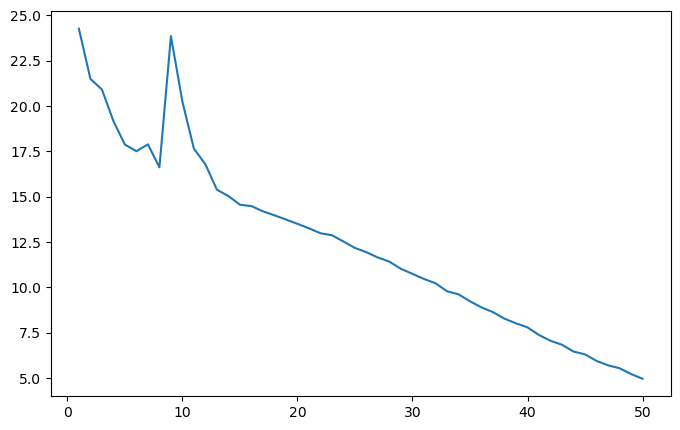

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["loss"], label="Training Loss")
plt.plot(epochs, history["val_total_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["class_loss"], label="Training Class")
plt.plot(epochs, history["val_class_loss"], label="Validation Class")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Class Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["box_loss"], label="Training Box")
plt.plot(epochs, history["val_box_loss"], label="Validation Box")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Box Loss")
plt.legend()
plt.grid(True)
plt.show()